**Problem 4**

Suppose there are three drug treatments (Drug A, Drug B, and Drug C) with the outcome of disease or no disease. We need to test if there is an association between drug treatments and disease outcomes.

Treatment	No Disease	Disease
Drug A	40	10
Drug B	10	40
Drug C	25	25

Perform Fisher’s exact test for the above contingency table, conduct a post-hoc test for Fisher’s exact test, and interpret your findings.

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Create Contingency Table
table = pd.DataFrame({
    'No_Disease': [40, 10, 25],
    'Disease': [10, 40, 25]
},
index=['Drug_A', 'Drug_B', 'Drug_C'])

print(table)


        No_Disease  Disease
Drug_A          40       10
Drug_B          10       40
Drug_C          25       25


In [3]:
#Overall Association Test
#Since Fisher’s Exact Test in scipy works directly only for 2×2 tables, we first use Chi-Square to check overall association.
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

Chi-square Statistic: 36.0
Degrees of Freedom: 2
P-value: 1.522997974471264e-08


**Interpretation of Overall Association Test**

The chi-square test results indicate a statistically significant association between drug treatment and disease outcome.

Chi-square statistic = 36.0
Degrees of freedom = 2
p-value = 1.52 × 10⁻⁸

Since:

p<0.05

we reject the null hypothesis of independence.

This suggests that disease outcomes differ significantly across the three drug treatments, indicating that treatment type may influence disease status.

**Pairwise Fisher’s Exact Tests**

We compare drugs pairwise:

A vs B
A vs C
B vs C



**Hypotheses**

Null Hypothesis

H0 :Treatment and disease outcome are independent

Alternative Hypothesis

H1 :Treatment and disease outcome are associated

In [4]:
#A vs B
AB = np.array([
    [40, 10],
    [10, 40]
])

oddsratio_AB, p_AB = fisher_exact(AB)

print("A vs B")
print("Odds Ratio:", oddsratio_AB)
print("P-value:", p_AB)

A vs B
Odds Ratio: 16.0
P-value: 2.2221008148312167e-09


In [5]:
#A vs C
AC = np.array([
    [40, 10],
    [25, 25]
])

oddsratio_AC, p_AC = fisher_exact(AC)

print("A vs C")
print("Odds Ratio:", oddsratio_AC)
print("P-value:", p_AC)

A vs C
Odds Ratio: 4.0
P-value: 0.0030520593364333462


In [6]:
#B vs C
BC = np.array([
    [10, 40],
    [25, 25]
])

oddsratio_BC, p_BC = fisher_exact(BC)

print("B vs C")
print("Odds Ratio:", oddsratio_BC)
print("P-value:", p_BC)

B vs C
Odds Ratio: 0.25
P-value: 0.0030520593364333462


In [8]:
#Multiple Testing Correction

#Bonferroni correction:

p_values = [p_AB, p_AC, p_BC]

adjusted = multipletests(
    p_values,
    method='bonferroni'
)

print("Adjusted P-values:")
print(adjusted[1])

Adjusted P-values:
[6.66630244e-09 9.15617801e-03 9.15617801e-03]


In [9]:
#Create Summary Table
results = pd.DataFrame({
    'Comparison': ['A vs B', 'A vs C', 'B vs C'],
    'P-value': p_values,
    'Adjusted P-value': adjusted[1]
})

print(results)

  Comparison       P-value  Adjusted P-value
0     A vs B  2.222101e-09      6.666302e-09
1     A vs C  3.052059e-03      9.156178e-03
2     B vs C  3.052059e-03      9.156178e-03


**Interpretation of Pairwise Fisher’s Exact Tests**

The pairwise Fisher’s exact tests with Bonferroni correction show significant differences between all drug treatment pairs.

Drug A vs Drug B: adjusted p-value = 6.67 × 10⁻⁹
Drug A vs Drug C: adjusted p-value = 0.009
Drug B vs Drug C: adjusted p-value = 0.009

Since all adjusted p-values are less than 0.05, we conclude that the disease outcomes differ significantly among all treatment groups.

The strongest difference is observed between Drug A and Drug B, suggesting these two treatments have substantially different effects on disease outcomes.

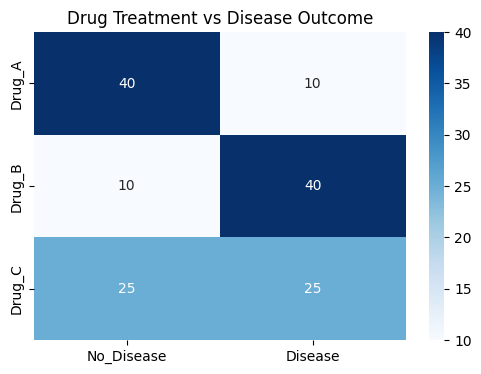

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    table,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Drug Treatment vs Disease Outcome")

plt.show()